# Lesson 108 · Temporal neighbor sampling: spend context carefully

Student lab · Three live tasks. Default CPU run authenticates the full dataset and benchmarks every source query. The ten-checkpoint author GPU experiment is separate and explicitly identified below. No learner completion is inferred.

In [ ]:
# @colab-bootstrap — standalone CPU teaching runtime, separate from pinned GPU replay.
import sys,subprocess,importlib.metadata
required={'numpy':'2.5.0','torch':'2.13.0','pandas':'3.0.3','scikit-learn':'1.9.0'}
missing=[]
for package,version in required.items():
    try: current=importlib.metadata.version(package).split('+')[0]
    except importlib.metadata.PackageNotFoundError: current=None
    if current!=version: missing.append(package+'=='+version)
if missing: subprocess.check_call([sys.executable,'-m','pip','install',*missing])
print('Python',sys.version.split()[0], 'teaching pins',required)


<p class="stream-label">One skill: make temporal queries faster without losing their meaning</p>

A node has interacted a million times. A prediction needs its history, but loading all of it for every query is expensive. **By the end, you will implement a bounded temporal sampler and defend a measured speed–accuracy trade-off.** This is directly useful when a relational model reads linked records as they existed at a particular time.

L107 compressed events into snapshots. Here we retain individual event times and reduce how much history a query reads. The key distinction is between **finding the same records faster** and **choosing different records**. Only the first should preserve predictions exactly.



## First retrieve, without notes



1. At time 8, can an event stamped exactly 8 enter a strict-past prediction?
2. If two systems score the same positives against different negatives, is their accuracy difference a clean model comparison?
3. What information does an hourly count snapshot lose?

<details><summary>Check after writing your answers</summary>

No: strict-past means event time < query time. Different negative candidates change the evaluation problem. A count snapshot loses within-window event order and exact times. Revisit [L104](https://avistian.github.io/relational/lessons/0104-information-leakage-in-time.html), [L106](https://avistian.github.io/relational/lessons/0106-temporal-link-prediction.html), and [L107](https://avistian.github.io/relational/lessons/0107-snapshot-methods.html) if needed.

</details>



## 1 · Find the legal interval before sampling

> **In plain terms.** First decide what this query is allowed to know. Only then decide which allowed records to read.

A **temporal query** is a node together with a cutoff time, written `(node, cutoff)`. A **recency window** is a duration W that limits how old a record may be. Our legal interval is `[cutoff − W, cutoff)`: include the left endpoint and exclude the right. With no age limit, W is infinity. The cutoff remains strict.

**Worked example.** Node A has events at times `[1, 3, 3, 8, 11]`. At cutoff 8 with W = 5, the legal timestamps are `[3, 3]`. Both events at time 3 remain distinct records. The event at 8 is unavailable. Never resolve a timestamp tie by arbitrary file order unless your data supplies a genuine within-time ordering contract.

<figure class="stream-figure" tabindex="0">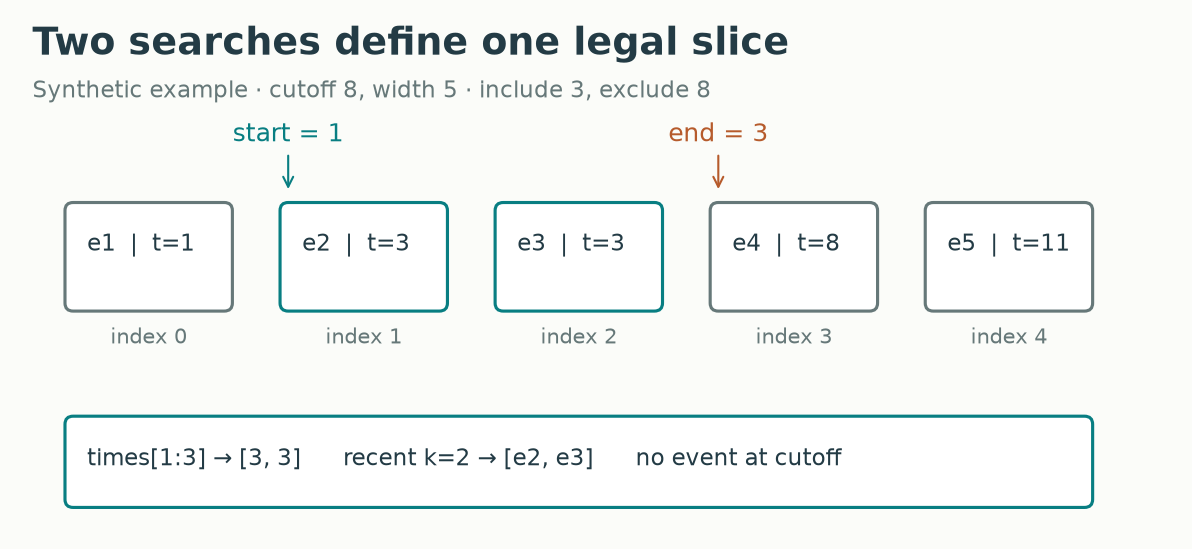<figcaption>Synthetic boundary calculation: two left searches retain both time-3 events and exclude the cutoff tie at 8.</figcaption></figure>

A sorted array makes this interval cheap to locate. **Binary search** repeatedly halves a candidate range. `searchsorted(times, boundary, side='left')` returns the first position whose value is at least the boundary. Two left searches give the start and end of our half-open slice. In the example they return 1 and 3; `times[1:3]` contains two records.

Implement `window_bounds` in the live TODO below.

**Predict, then change the controls:** move the cutoff from 8 to 9 with W fixed at 5. Does time 3 remain eligible? Does time 8 enter?

**Portable intervention:** at cutoff 9 and width 5, [4,9) retains only time 8. Recent k=2 adds one padding slot.

<details><summary>Worked answer, including a no-JavaScript fallback</summary>

The new interval is [4, 9), so both time-3 events expire and time 8 enters. With recent fanout 2, the result has one real event and one padding slot. At the original [3, 8), recent fanout 1 retains the later event ID among the two time-3 records. That deterministic tie rule selects records; it does not permit equal-cutoff events.

</details>

> **Scope check.** Wikipedia records event time, not ingestion time. We assume availability equals event time. Late-arriving database records need L104's additional availability check; an event-time index alone cannot certify that a record was known then. A recency window also does not imply a future prediction horizon.



## 2 · Bound the work, and state the sampling distribution

**Fanout k** is the maximum number of neighbor slots produced per query. Each sampled record carries three aligned values: neighboring node ID, event ID, and event timestamp. Edge features are retrieved by event ID later.

**Uniform with replacement** draws k independent positions from the legal records. If only two records exist and k = 4, the sample might be `[0, 1, 0, 1]`. Duplicates are intentional; k is not the number of distinct neighbors. We sort the selected records by time before returning them.

**Recent sampling** keeps the last min(k, count) eligible records. Missing slots are padded on the left. ID 0 denotes padding and has a separate mask; it is not an observed edge at time zero. The adapter preserves Wikipedia’s integer timestamps exactly in float32; larger absolute timestamps or fractional timestamps need a precision audit before reuse. A model's behavior on an entirely padded row still depends on its attention implementation. The preserved TGAT release uses a finite masking value, and an all-padding row does not automatically imply a zero embedding.

Implement `choose_positions` in the live TODO below.

The readable reference calls these two student functions directly. The optimized implementation performs the same arithmetic over arrays. The lab requires sample-for-sample agreement, including duplicate choices, tie ordering and padding. A wrong TODO cannot pass simply because the optimized code is correct.

The [TGAT authors describe temporal neighborhood sampling and subgraph batching in §3.4](https://arxiv.org/html/2002.07962v1#S3.SS4). Their [released experiment uses uniform sampling and fanout 20](https://github.com/StatsDLMathsRecomSys/Inductive-representation-learning-on-temporal-graphs/tree/9293d10d1943c4bd4a186337cf38ba98e4c8bb99). Our recent/window variants are explicit course interventions.



## 3 · Store once, search many queries together

A **compressed adjacency index** stores all neighbor records in flat arrays. An offsets array says where each node's row starts and stops. Within a row, records are sorted by `(timestamp, event ID)`. A row can be empty. This lab inserts each interaction in both endpoint rows, matching TGAT's undirected neighborhood view; the prediction question still has a source and destination.

For B queries, two batched binary searches maintain B lower/upper position pairs. At each step, all unfinished searches compare their own midpoint against their own cutoff. A query never searches another node's row. After finding eligible slices, we gather at most B × k records.

<figure class="stream-figure" tabindex="0">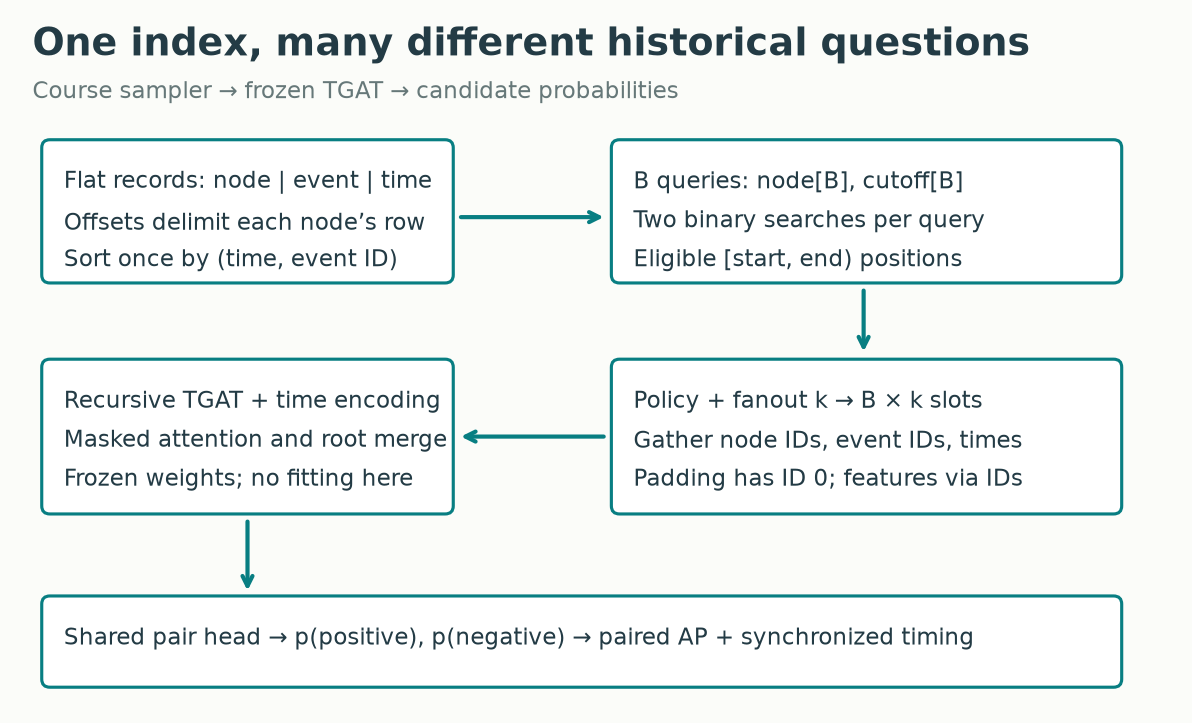<figcaption>The sampler returns aligned B-by-k identities and timestamps; frozen TGAT turns this context into positive and negative scores.</figcaption></figure>

**Shapes.** Nodes and cutoffs have shape `[B]`. Each returned array has shape `[B, k]`. The model gathers `[B, k, F]` edge and node features, where F is feature width. TGAT recursively encodes neighbors, combines those vectors with elapsed-time encodings and edge features, applies masked attention, and merges the result with the source representation. A shared pair-scoring network produces positive and negative probabilities. Training minimizes positive/negative binary cross-entropy; this lesson loads frozen trained weights and changes only their context.

**Work.** For a row of d events, binary search costs O(log d) comparisons: the number grows logarithmically with history length. Gathering costs O(k) per query. Sorting sampled timestamps adds O(k log k). The implementation does not scan the full history on every query. Construction sorts the original records once and stores O(E + N) values, where E counts interactions and N counts nodes. Two endpoint rows mean approximately 2E stored records.

**Memory boundary.** A finite window reduces eligible records but this offline implementation retains the complete index. The window therefore does **not** reduce its persistent memory. Online expiration could reclaim old records, but then later replay of earlier queries would require another store. Report index-array bytes separately from temporary arrays, process memory and GPU tensors.



## 4 · The second hop must inherit the edge time

> **In plain terms.** A neighbor seen yesterday must be represented using what was known yesterday, even when today's root query can see more.

**Worked example.** A query for A at 8 traverses an A–B edge at 3. When encoding B on that path, TGAT passes cutoff **3**, not 8. A B–C edge at 6 is therefore excluded. Reusing the root cutoff would change the path's temporal meaning.

<figure class="stream-figure" tabindex="0">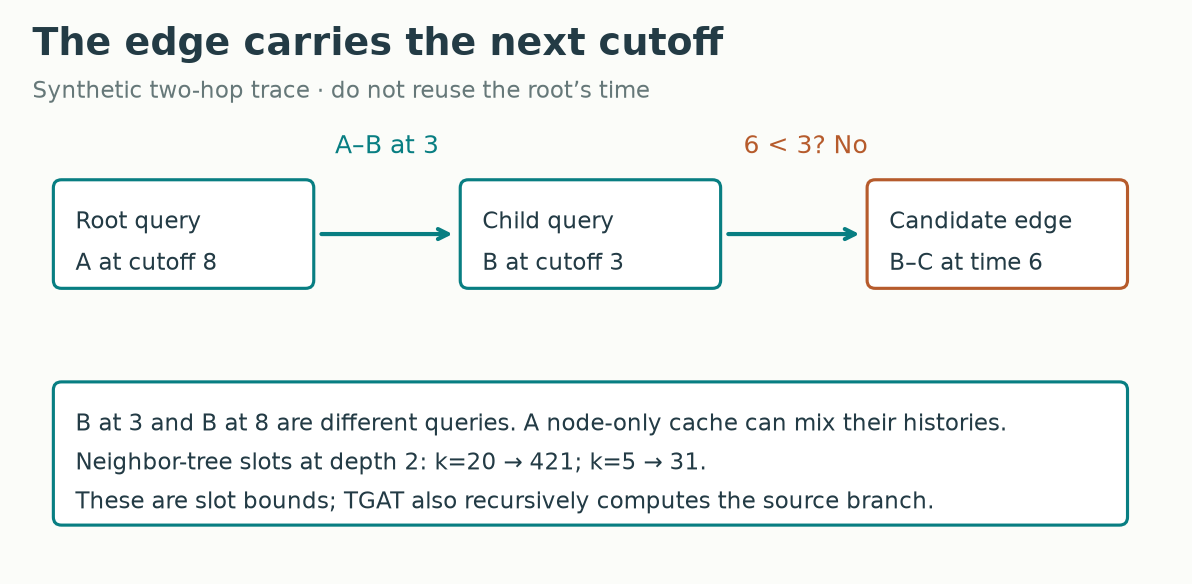<figcaption>The A–B edge at 3 passes cutoff 3 into B’s next query. A B–C edge at 6 is excluded on this path.</figcaption></figure>

The index is queried once per `(node, cutoff)` pair. Two visits to node B at different cutoffs may have different valid histories. A cache keyed only by node ID is unsafe. Even a `(node, cutoff)` cache needs layer, sampler policy, window, model state and stochastic-sampling semantics considered; reusing a random sample can change the estimator's dependence structure. This lesson does not introduce such a cache.

For neighbor expansion alone, L layers with constant fanout k can expose up to `1 + k + k² + … + kᴸ` tree slots per root before deduplication. With two layers, k = 20 gives 421; k = 5 gives 31. These are **tree slot bounds**, not unique nodes, exact FLOPs, or memory measurements. This TGAT implementation also recursively computes the source representation at each layer, and scores source, positive destination and negative destination. Its actual work exceeds the neighbor-tree sketch; use measured inference timing.

**Check:** two queries request B at times 3 and 8. Can they share the same latest embedding solely because their node IDs match? Explain a counterexample before opening the answer.

<details><summary>Check the cache counterexample</summary>

If B has an edge at 6, the time-8 query may use it and the time-3 query may not. Reusing the later representation leaks information into the earlier one. A node ID identifies an entity, not its information state.

</details>



## 5 · Define the experiment before inspecting accuracy

**Predict first:** does lower fanout guarantee identical accuracy? Write why before examining the measurements.

**Optimization experiment.** Run the scalar and batched samplers over all 157,474 Wikipedia source-node queries. Fix queries, fanout 20, unlimited history, uniform variates and output order. Check every sampled node, event ID and timestamp. Warm both implementations, alternate their order, and measure three repetitions. Timings exclude random-number generation, index construction and neural inference; construction is reported separately.

**Full checkpoint evaluation.** Load all ten completed L103 TGAT checkpoints. First replay the released Wikipedia all-event and new-node evaluations, preserving the release's boundary omission, negative sampler, random state and batch aggregation. Check every probability against the archived run. Then evaluate four strict-past interventions on the same question IDs, negative candidates and batches:

| Condition | Neighbor slots | Eligible history | Selection |
|---|---:|---|---|
| uniform20 | 20 | All strictly earlier records | Uniform with replacement |
| uniform5 | 5 | All strictly earlier records | Uniform with replacement |
| recent20 | 20 | All strictly earlier records | Most recent records |
| day20 | 20 | Previous 86,400 seconds | Uniform with replacement |

Weights are frozen; no test result selects a configuration. Both all-event and new-node populations are evaluated completely under the archived release question contract. Their populations overlap, so they are not independent datasets. We reset each condition's random seed, but changing fanout changes recursive draw consumption: this is paired **question** evaluation, not exact random-number coupling across all conditions.

**Measure accuracy.** Average precision (AP) summarizes ranking precision at observed positive retrievals. The released paper comparison averages AP over batches. The intervention table pools all predictions within each population, computes one AP per seed, then averages those ten values. These aggregations answer different questions and must not be substituted. The paper's 95.34% and 93.99% targets belong only to the released batch-mean comparison.

**Measure speed.** Synchronize the GPU before and after each measured inference pass. Include temporal sampling, feature gathering, model computation, host transfers and prediction collection. Report positive questions per second, each accompanied by one negative. Rotate condition order across seeds. This is one full timing pass per condition/checkpoint; variation includes checkpoint and hardware scheduling differences. It is not a statistical confidence interval for production latency.

**Author-reference evidence:** these numbers are not output from your current notebook kernel.

**Measured CPU sampler:** 157,474 queries; scalar median 2.025 s, batched median 0.259 s, **7.82× speedup**. Every sample matched. The index stores 7,632,608 array bytes (7.28 MiB); construction took 0.023 s. Three warmed repetitions on the local ARM64 CPU, batch 200; random draws were prepared before timing.

**Released-evaluation replay:** all ten checkpoints; all batch-mean AP 95.2825% ± 0.2784 pp seed SD (paper 95.34%, CLOSE); new batch-mean AP 93.7792% ± 0.3912 pp seed SD (paper 93.99%, CLOSE). Maximum absolute probability difference from archived evaluation: 0. This uses 23,620 all-event and 11,714 new-node positives per seed; the released batching omits the final event in each population.

| Policy | All AP (%) | All Δ (pp) | All questions/s | New AP (%) | New Δ (pp) | Peak GPU MiB |
|---|---:|---:|---:|---:|---:|---:|
| uniform20 | 95.866 ± 0.204 | 0.000 ± 0.000 | 1018 | 94.843 ± 0.306 | 0.000 ± 0.000 | 372.0 |
| uniform5 | 84.296 ± 0.352 | -11.570 ± 0.271 | 1666 | 82.780 ± 0.558 | -12.064 ± 0.376 | 257.2 |
| recent20 | 96.501 ± 0.092 | 0.636 ± 0.198 | 1062 | 96.017 ± 0.097 | 1.174 ± 0.289 | 372.0 |
| day20 | 95.738 ± 0.092 | -0.128 ± 0.186 | 1048 | 95.522 ± 0.108 | 0.679 ± 0.323 | 372.0 |

AP and paired differences show mean ± sample SD over ten seeds. Throughput is mean positive questions/second, each with one negative. Peak GPU allocated bytes include the loaded model and tensors; CPU index-array bytes are separate. The GPU is an NVIDIA T4. Neither statistic measures whole-system peak resident memory.

All 1,413,360 intervention positive questions were evaluated, each with one negative; all recursive access audits found zero nonpast or expired sampled records. New-node and all-event counts overlap. Independent metric reconstruction passed.

**Read the trade-off:** reducing fanout from 20 to 5 delivered 1.64× measured inference throughput, but lost 11.57 AP percentage points on all-event questions. Recent-20 gained 0.64 points. These weights were trained with fanout 20: changing context at inference can create a substantial distribution shift. This experiment does not isolate which internal attention behavior caused the loss. The 421/31 tree-slot ratio is not the measured speed ratio.

<figure class="stream-figure" tabindex="0">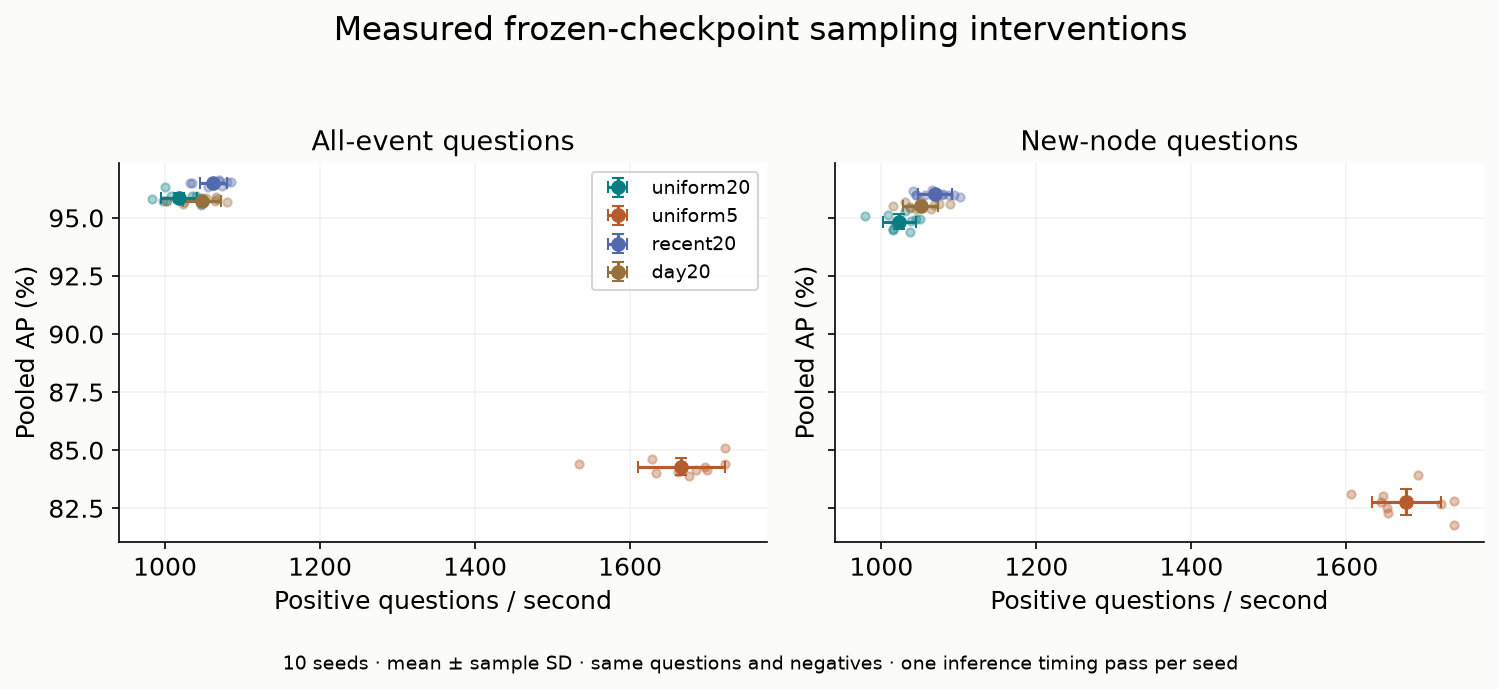<figcaption>Author experiment: same questions and negatives, four fixed-weight inference interventions, ten seeds. Points show seeds; bars show sample SD, not confidence intervals.</figcaption></figure>

**Interpret the result before choosing a policy.** Compare changed-minus-uniform20 AP within each seed. A smaller fanout reduces requested context; a short window removes older records; recent selection changes which interactions receive attention. A higher AP in one frozen model is evidence for that measured intervention, not proof the policy is optimal after retraining. Wikipedia is a moderate-sized graph; synthetic expansion counts do not establish performance on a billion-edge production graph.



## 6 · Reproduction boundary and lab

The [reproduction contract](https://avistian.github.io/relational/labs/l108-reproduction.md) pins source, raw data, processed arrays, splits, ten checkpoints, configuration, runtime and output hashes. It provides local and GPU commands, the full training route inherited from L103, a budget ledger and independent reconstruction of metrics from saved predictions.

> **Scope check.** The selected Wikipedia evaluation replay is complete when all ten outputs pass the recorded checks. L108 does not retrain those checkpoints. Modern-runtime replay and close table values do not establish historical identity or reproduction of the entire TGAT paper. Reddit, node classification, fresh sampler-specific training, live Colab and deployment have separate unrun/unchecked statuses.

Open the [student notebook](https://avistian.github.io/relational/labs/0108-temporal-neighbor-sampling.ipynb), [executed solution](https://avistian.github.io/relational/labs/html/0108-temporal-neighbor-sampling.html), or [downloadable solution](https://avistian.github.io/relational/labs/solutions/0108-temporal-neighbor-sampling.ipynb). The notebook is standalone: portable diagrams, visible sampler, complete TGAT model/trainer, three TODO/CHECK tasks, raw-data authentication and a full-data sampler benchmark. The expensive ten-checkpoint GPU evaluation is a separately executed author experiment, with an explicit rerun command.

**TODO 1:** implement half-open window boundaries, including ties and singleton histories. **TODO 2:** implement uniform replacement and recent padding. **TODO 3:** implement the neighbor-expansion budget and explain why it is not exact model cost. Then run the full-data reference-versus-batched equality check: the first two TODOs are on that executed reference path.



## EXIT · defend one temporal batch

Without opening your notes, submit:

1. Your three implementations and a new boundary fixture that catches a plausible bug.
2. A two-hop trace showing a root cutoff, selected edge time and next-hop cutoff.
3. The measured equality check, throughput ratio, index bytes and a warning about what the timing excludes.
4. A sampling policy recommendation supported by paired AP and measured inference time, plus one reason it may change after retraining.
5. A sentence distinguishing source replay, inference intervention, full-paper reproduction and your own learner evidence.

**Write your temporal batch defense before consulting the solution.**

**Spacing:** tomorrow, derive [cutoff − W, cutoff) and explain the cache counterexample without notes. In one week, implement the boundary test from a fresh example. Prepared material remains **PENDING_WRITTEN_DEFENSE** until you supply learner evidence.

**Primary reading:** [Xu et al., TGAT §3.4 and Appendix A.6](https://arxiv.org/html/2002.07962v1). Read it alongside the [pinned released sampler](https://github.com/StatsDLMathsRecomSys/Inductive-representation-learning-on-temporal-graphs/blob/9293d10d1943c4bd4a186337cf38ba98e4c8bb99/graph.py), watching for differences between intended recency and actual slicing. Ask the teaching agent about any unclear code, boundary or measured result; bring your EXIT defense for critique.

[Quick reference](https://avistian.github.io/relational/reference/temporal-sampling.html) · [Previous: snapshot methods](https://avistian.github.io/relational/lessons/0107-snapshot-methods.html) · **Next: L109** maps these query cutoffs to database `created_at` and `observed_at` semantics.


## Implement and test the sampler

The first two tasks define the readable reference actually used below. The third predicts an upper bound on neighbor-tree slots. The optimized sampler is PROVIDED and must match your reference; it does not silently replace your answers.

### Imports

In [ ]:
import time
import numpy as np

### TODO 1 — define the legal interval

In [ ]:
def window_bounds(sorted_times, cutoff, window=np.inf):
    """Return [start,end) positions for timestamps in [cutoff-window,cutoff)."""
    raise NotImplementedError("TODO: window_bounds")

### CHECK · window_bounds

In [ ]:
assert window_bounds(np.array([1.,3.,3.,8.]),3,2)==(0,1), 'Cutoff ties must be excluded'
assert window_bounds(np.array([1.,3.,3.,8.]),8,5)==(1,3), 'Lower window boundary is included'
assert window_bounds(np.array([1.]),2)==(0,1), 'A singleton history is useful'
assert window_bounds(np.array([]),2)==(0,0)
print('PASS: half-open boundary, ties, empty and singleton')

### TODO 2 — spend a bounded neighbor budget

In [ ]:
def choose_positions(count, fanout, policy, uniforms):
    """Relative positions, with -1 for padding; uniform draws use replacement."""
    raise NotImplementedError("TODO: choose_positions")

### CHECK · choose_positions

In [ ]:
assert choose_positions(3,5,'recent',np.zeros(5)).tolist()==[-1,-1,0,1,2]
assert choose_positions(2,4,'uniform',np.array([.1,.9,.1,.9])).tolist()==[0,1,0,1]
assert choose_positions(0,3,'uniform',np.zeros(3)).tolist()==[-1,-1,-1]
print('PASS: recent padding and uniform replacement')

### TODO 3 — predict recursive expansion

In [ ]:
def expansion_size(layers, fanout):
    """Tree upper bound per root: 1 + k + ... + k**L, before deduplication."""
    raise NotImplementedError("TODO: expansion_size")

### CHECK · expansion_size

In [ ]:
assert expansion_size(0,20)==1
assert expansion_size(2,20)==421
assert expansion_size(2,5)==31
assert expansion_size(3,1)==4
print('PASS: neighbor-tree bound; extra source recursion is not counted')

### Compressed temporal rows — one flat record array, offsets delimit nodes

In [ ]:
class TemporalIndex:
    def __init__(self, events, n_nodes):
        u=np.asarray(events['u'],dtype=np.int64);v=np.asarray(events['v'],dtype=np.int64)
        t=np.asarray(events['t'],dtype=np.float64);e=np.asarray(events['e'],dtype=np.int64)
        if not (u.shape==v.shape==t.shape==e.shape) or not np.isfinite(t).all():raise ValueError('Invalid events')
        if len(u) and (min(u.min(),v.min())<1 or max(u.max(),v.max())>=n_nodes):raise ValueError('Node 0 is padding')
        owner=np.r_[u,v];neighbor=np.r_[v,u];ts=np.r_[t,t];edges=np.r_[e,e]
        order=np.lexsort((edges,ts,owner))
        # Sentinel lets empty output gathers remain valid even for an empty graph.
        self.nodes=np.r_[0,neighbor[order]].astype(np.int64)
        self.edges=np.r_[0,edges[order]].astype(np.int64)
        self.times=np.r_[0.,ts[order]]
        self.offsets=np.r_[1,1+np.cumsum(np.bincount(owner,minlength=n_nodes))]
        self.n_nodes=n_nodes
        self.policy='uniform';self.window=np.inf
        self.audit={'queries':0,'sampled_records':0,'nonpast_records':0,'expired_records':0}

    @property
    def array_bytes(self):
        return sum(a.nbytes for a in (self.nodes,self.edges,self.times,self.offsets))

    def lower_bound(self, nodes, boundaries):
        """Batched binary search: each query searches only its node's row."""
        lo=self.offsets[nodes].copy();hi=self.offsets[nodes+1].copy()
        while np.any(lo<hi):
            active=lo<hi;mid=(lo+hi)//2
            probe=self.times[np.minimum(mid,len(self.times)-1)]
            right=active & (probe<boundaries)
            lo=np.where(right,mid+1,lo);hi=np.where(active & ~right,mid,hi)
        return lo

    def sample(self,nodes,cutoffs,fanout=20,policy='uniform',window=np.inf,uniforms=None):
        """Bounded [B,k] outputs (node,event,time); masks encoded by event 0."""
        nodes=np.asarray(nodes,dtype=np.int64);cutoffs=np.asarray(cutoffs,dtype=float)
        if nodes.shape!=cutoffs.shape or nodes.ndim!=1 or not np.isfinite(cutoffs).all():raise ValueError('Invalid queries')
        if np.any(nodes<0) or np.any(nodes>=self.n_nodes):raise ValueError('Unknown node')
        if fanout<1 or policy not in ('uniform','recent') or not window>0:raise ValueError('Invalid config')
        start=self.lower_bound(nodes,cutoffs-window);end=self.lower_bound(nodes,cutoffs)
        count=end-start
        draws=np.random.random((len(nodes),fanout)) if uniforms is None else np.asarray(uniforms)
        if draws.shape!=(len(nodes),fanout) or not ((draws>=0)&(draws<1)).all():raise ValueError('Invalid variates')
        if policy=='uniform':
            pos=start[:,None]+np.floor(draws*count[:,None]).astype(np.int64)
            valid=np.broadcast_to(count[:,None]>0,pos.shape)
        else:
            pos=end[:,None]+np.arange(-fanout,0)
            valid=pos>=start[:,None]
        pos=np.where(valid,pos,0)
        # Stable chronological output; padding precedes real history, including time zero.
        ordering=np.argsort(np.where(valid,self.times[pos],-np.inf),axis=1,kind='stable')
        pos=np.take_along_axis(pos,ordering,axis=1)
        result=(self.nodes[pos].astype(np.int32),self.edges[pos].astype(np.int32),self.times[pos].astype(np.float32))
        mask=result[1]!=0
        self.audit['queries']+=len(nodes);self.audit['sampled_records']+=int(mask.sum())
        self.audit['nonpast_records']+=int(np.sum(mask & (self.times[pos]>=cutoffs[:,None])))
        self.audit['expired_records']+=int(np.sum(mask & (self.times[pos]<cutoffs[:,None]-window)))
        return result

    def sample_scalar(self,nodes,cutoffs,fanout=20,policy='uniform',window=np.inf,uniforms=None):
        """Readable reference: student's boundary and policy are on this live path."""
        draws=np.random.random((len(nodes),fanout)) if uniforms is None else uniforms
        result=[np.zeros((len(nodes),fanout),dtype=d) for d in (np.int32,np.int32,np.float32)]
        for i,(node,cutoff) in enumerate(zip(nodes,cutoffs)):
            base,stop=self.offsets[node:node+2]
            lo,hi=window_bounds(self.times[base:stop],cutoff,window)
            chosen=choose_positions(hi-lo,fanout,policy,draws[i]);valid=chosen>=0
            positions=np.where(valid,base+lo+chosen,0)
            order=np.argsort(np.where(valid,self.times[positions],-np.inf),kind='stable');positions=positions[order]
            for out,arr in zip(result,(self.nodes,self.edges,self.times)):out[i]=arr[positions]
        return tuple(result)

    def get_temporal_neighbor(self,nodes,cutoffs,num_neighbors=20):
        """TGAT adapter: recursive model calls supply each edge's own timestamp."""
        return self.sample(nodes,cutoffs,num_neighbors,self.policy,self.window)

### Full data sampler benchmark — same questions and variates, no model inference

In [ ]:
def benchmark_sampler(events,n_nodes,batch_size=200,repeats=3):
    start=time.perf_counter();index=TemporalIndex(events,n_nodes);construction=time.perf_counter()-start
    queries=events['u'];cutoffs=events['t'];draws=np.random.default_rng(108).random((len(queries),20))
    for method in (index.sample_scalar,index.sample):method(queries[:batch_size],cutoffs[:batch_size],uniforms=draws[:batch_size])
    timings={'scalar':[],'batched':[]};equal=True
    for i in range(0,len(queries),batch_size):
        q=queries[i:i+batch_size];t=cutoffs[i:i+batch_size];u=draws[i:i+batch_size]
        a=index.sample_scalar(q,t,uniforms=u);b=index.sample(q,t,uniforms=u)
        equal &= all(np.array_equal(x,y) for x,y in zip(a,b))
    assert equal,'An optimization changed sampled events'
    # Alternate order to reduce systematic warm-cache/order confounding.
    for repeat in range(repeats):
      for name in (['scalar','batched'] if repeat%2==0 else ['batched','scalar']):
        method=index.sample_scalar if name=='scalar' else index.sample
        start=time.perf_counter()
        for i in range(0,len(queries),batch_size):method(queries[i:i+batch_size],cutoffs[i:i+batch_size],uniforms=draws[i:i+batch_size])
        timings[name].append(time.perf_counter()-start)
    return {'queries':len(queries),'batch_size':batch_size,'repeats':repeats,'construction_seconds':construction,'index_array_bytes':index.array_bytes,'timing_seconds':timings,'samples_exactly_equal':bool(equal),'scope':'CPU sampling only; fixed precomputed random variates; array bytes exclude allocator and temporary arrays'}

## Complete TGAT model, preprocessing and trainer

Provided for independent reading and reproduction. This is the unchanged L103 reconstruction of the pinned released attention variant. The code is visible in chunks, including selection and training; default notebook execution defines the trainer but does not train a new checkpoint. `release=True` preserves release behavior. Our new sampler is substituted only for the declared interventions.

### PROVIDED · Imports and frozen identities

In [ ]:
import copy
import hashlib
import json
import math
import random
import time
import urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.metrics import average_precision_score, roc_auc_score
SOURCE_COMMIT='9293d10d1943c4bd4a186337cf38ba98e4c8bb99'
DATA_URL='https://snap.stanford.edu/jodie/wikipedia.csv'
DATA_SHA256='a6b73e09c0d1e5b9db11e7e7aa416f2e87838a745273e0446a79952cf4cfae09'
PAPER_AP={'all':95.34,'new':93.99}
CLOSE_TOLERANCE_PP=0.5

### PROVIDED · Task 1: functional time encoding, release parameterization

In [ ]:
def encode_time(elapsed, frequency, phase):
    """Map elapsed [B,N] and trainable [D] frequencies/phases to [B,N,D]."""
    return torch.cos(elapsed.unsqueeze(-1)*frequency+phase)

### PROVIDED · Task 2: scaled masked attention

In [ ]:
def attention_weights(query, keys, padding):
    """[H*B,1,D] x [H*B,N,D] -> [H*B,1,N]; True means padding.
    Preserve the release's finite -1e10 mask, including uniform all-padding rows.
    """
    scores=torch.bmm(query,keys.transpose(1,2))/math.sqrt(query.shape[-1])
    return torch.softmax(scores.masked_fill(padding,-1e10),dim=-1)

### PROVIDED · Task 3: strict-past temporal boundary for the corrected comparison

In [ ]:
def strict_prefix(sorted_times, cutoff):
    """Number of events strictly before cutoff; exclude every equal timestamp."""
    return int(np.searchsorted(sorted_times,cutoff,side='left'))

### PROVIDED · Temporal neighborhoods: declared release behavior or corrected boundary

In [ ]:
class NeighborFinder:
    def __init__(self, events, n_nodes, release=True, uniform=True):
        rows=[[] for _ in range(n_nodes)]
        for u,v,t,e in zip(events['u'],events['v'],events['t'],events['e']):
            rows[int(u)].append((int(v),int(e),float(t)))
            rows[int(v)].append((int(u),int(e),float(t)))
        # Release sorts by edge ID. For this stream, IDs are chronological.
        self.rows=[np.asarray(sorted(r,key=lambda z:z[1] if release else z[2]),dtype=np.float64).reshape(-1,3) for r in rows]
        self.release,self.uniform=release,uniform
    def find_before(self,node,cutoff):
        a=self.rows[int(node)];ts=a[:,2]
        if not self.release:
            end=strict_prefix(ts,cutoff)
        elif not len(a):
            end=0
        else:
            # Exact released binary-search/slice convention, including its omitted item.
            left,right=0,len(a)-1
            while left+1<right:
                middle=(left+right)//2
                if ts[middle]<cutoff:left=middle
                else:right=middle
            end=right if ts[right]<cutoff else left
        return a[:end]
    def get_temporal_neighbor(self,nodes,cutoffs,num_neighbors=20):
        ids=np.zeros((len(nodes),num_neighbors),dtype=np.int32)
        edges=np.zeros_like(ids);times=np.zeros(ids.shape,dtype=np.float32)
        for i,(node,cutoff) in enumerate(zip(nodes,cutoffs)):
            history=self.find_before(node,cutoff)
            if not len(history):continue
            if self.uniform:
                chosen=history[np.random.randint(0,len(history),num_neighbors)]
                ids[i],edges[i],times[i]=chosen[:,0],chosen[:,1],chosen[:,2]
                order=times[i].argsort();ids[i],edges[i],times[i]=ids[i,order],edges[i,order],times[i,order]
            else:
                chosen=history[:num_neighbors] if self.release else history[-num_neighbors:]
                ids[i,-len(chosen):],edges[i,-len(chosen):],times[i,-len(chosen):]=chosen[:,0],chosen[:,1],chosen[:,2]
        return ids,edges,times

### PROVIDED · Trainable encoder and feed-forward merge

In [ ]:
class TimeEncoder(nn.Module):
    def __init__(self,dim):
        super().__init__()
        self.basis_freq=nn.Parameter(torch.tensor(1/10**np.linspace(0,9,dim),dtype=torch.float32))
        self.phase=nn.Parameter(torch.zeros(dim))
    def forward(self,elapsed):return encode_time(elapsed,self.basis_freq,self.phase)

class Merge(nn.Module):
    def __init__(self,left,right,hidden,out):
        super().__init__();self.fc1=nn.Linear(left+right,hidden);self.fc2=nn.Linear(hidden,out)
        nn.init.xavier_normal_(self.fc1.weight);nn.init.xavier_normal_(self.fc2.weight)
    def forward(self,left,right):return self.fc2(torch.relu(self.fc1(torch.cat([left,right],dim=-1))))

### PROVIDED · Multi-head attention: projection, aggregation, residual and normalization

In [ ]:
class MultiHead(nn.Module):
    def __init__(self,width,heads,dropout):
        super().__init__();assert width%heads==0
        self.heads,self.head_dim=heads,width//heads
        self.w_qs=nn.Linear(width,width,bias=False);self.w_ks=nn.Linear(width,width,bias=False);self.w_vs=nn.Linear(width,width,bias=False)
        for layer in [self.w_qs,self.w_ks,self.w_vs]:nn.init.normal_(layer.weight,std=np.sqrt(2/(width+self.head_dim)))
        self.layer_norm=nn.LayerNorm(width);self.fc=nn.Linear(width,width);nn.init.xavier_normal_(self.fc.weight)
        self.dropout=nn.Dropout(dropout)
    def forward(self,q,k,mask):
        batch=q.shape[0]
        def split(x,projection):
            return projection(x).view(batch,-1,self.heads,self.head_dim).permute(2,0,1,3).contiguous().view(self.heads*batch,-1,self.head_dim)
        query,keys,values=split(q,self.w_qs),split(k,self.w_ks),split(k,self.w_vs)
        weights=self.dropout(attention_weights(query,keys,mask.repeat(self.heads,1,1)))
        mixed=torch.bmm(weights,values).view(self.heads,batch,1,self.head_dim).permute(1,2,0,3).contiguous().view(batch,1,-1)
        return self.layer_norm(q+self.dropout(self.fc(mixed)))

class TemporalAttention(nn.Module):
    def __init__(self,dim,heads,dropout):
        super().__init__();self.merger=Merge(3*dim,dim,dim,dim);self.multi_head_target=MultiHead(3*dim,heads,dropout)
    def forward(self,source,zero_time,neighbors,elapsed,edge,padding):
        q=torch.cat([source[:,None,:],torch.zeros_like(source[:,None,:]),zero_time],dim=-1)
        kv=torch.cat([neighbors,edge,elapsed],dim=-1)
        context=self.multi_head_target(q,kv,padding[:,None,:]).squeeze(1)
        return self.merger(context,source)

### PROVIDED · Complete recursive TGAT encoder and shared positive/negative decoder

In [ ]:
class TGAT(nn.Module):
    def __init__(self,finder,node_features,edge_features,layers=2,heads=2,dropout=.1):
        super().__init__();self.num_layers=layers;self.ngh_finder=finder
        # Preserve release registration and initialization order for parity checks.
        self.n_feat_th=nn.Parameter(torch.as_tensor(node_features,dtype=torch.float32))
        self.e_feat_th=nn.Parameter(torch.as_tensor(edge_features,dtype=torch.float32))
        self.edge_raw_embed=nn.Embedding.from_pretrained(self.e_feat_th,padding_idx=0,freeze=True)
        self.node_raw_embed=nn.Embedding.from_pretrained(self.n_feat_th,padding_idx=0,freeze=True)
        d=node_features.shape[1];assert edge_features.shape[1]==d
        self.merge_layer=Merge(d,d,d,d) # unused released module, retained for RNG/state identity
        self.attn_model_list=nn.ModuleList([TemporalAttention(d,heads,dropout) for _ in range(layers)])
        self.time_encoder=TimeEncoder(d);self.affinity_score=Merge(d,d,d,1)
    def tem_conv(self,nodes,cutoffs,layer,num_neighbors=20):
        device=self.n_feat_th.device
        raw=self.node_raw_embed(torch.as_tensor(nodes,dtype=torch.long,device=device))
        if layer==0:return raw
        source=self.tem_conv(nodes,cutoffs,layer-1,num_neighbors)
        nbr,eid,when=self.ngh_finder.get_temporal_neighbor(nodes,cutoffs,num_neighbors)
        child=self.tem_conv(nbr.ravel(),when.ravel(),layer-1,num_neighbors).reshape(len(nodes),num_neighbors,-1)
        elapsed=torch.as_tensor(cutoffs[:,None]-when,dtype=torch.float32,device=device)
        time_features=self.time_encoder(elapsed)
        zero_time=self.time_encoder(torch.zeros((len(nodes),1),device=device))
        edge=self.edge_raw_embed(torch.as_tensor(eid,dtype=torch.long,device=device))
        padding=torch.as_tensor(nbr==0,device=device)
        return self.attn_model_list[layer-1](source,zero_time,child,time_features,edge,padding)
    def contrast(self,u,v,negative,t,num_neighbors=20):
        src=self.tem_conv(u,t,self.num_layers,num_neighbors)
        dst=self.tem_conv(v,t,self.num_layers,num_neighbors)
        neg=self.tem_conv(negative,t,self.num_layers,num_neighbors)
        return self.affinity_score(src,dst).flatten().sigmoid(),self.affinity_score(src,neg).flatten().sigmoid()

### PROVIDED · Hash-checked raw Wikipedia preprocessing and frozen temporal split

In [ ]:
def load_wikipedia(directory):
    directory = Path(directory); directory.mkdir(parents=True, exist_ok=True)
    path = directory/'wikipedia.csv'
    if not path.exists():
        urllib.request.urlretrieve(DATA_URL, path)
    sha = hashlib.file_digest(path.open('rb'), 'sha256').hexdigest()
    assert sha == DATA_SHA256, f'Dataset checksum mismatch: {sha}'
    cache = directory/'processed.npz'
    if cache.exists():
        z = np.load(cache)
        # The raw identity alone cannot authenticate an arbitrary processed cache.
        if str(z['raw_sha']) != sha:
            raise ValueError('Processed cache belongs to other raw bytes')
        u,v,t,x = (z[k] for k in ['u','v','t','x'])
    else:
        # Header has four columns, rows additionally have 172 edge features.
        a = np.loadtxt(path, delimiter=',', skiprows=1)
        u = a[:, 0].astype(np.int64)+1
        v = a[:, 1].astype(np.int64)+int(u.max())+1
        t,x = a[:, 2], a[:, 4:].astype(np.float32)
        np.savez(cache, u=u,v=v,t=t,x=x,raw_sha=sha)
    assert len(u)==157474 and x.shape==(157474,172)
    assert np.all(np.diff(t)>=0) and len(set(u)|set(v))==9227
    edges = np.vstack([np.zeros((1,172),np.float32),x])
    nodes = np.zeros((int(max(u.max(),v.max()))+1,172),np.float32)
    full = {'u':u,'v':v,'t':t,'e':np.arange(1,len(u)+1)}
    val_time,test_time = np.quantile(t,[.70,.85])
    candidates = set(u[t>val_time]) | set(v[t>val_time])
    # Python 3.9 random.sample(set, k) internally converted to tuple. Preserve that order.
    held = set(random.Random(2020).sample(tuple(candidates),int(.1*(len(nodes)-1))))
    train_mask = (t<=val_time)&~np.isin(u,list(held))&~np.isin(v,list(held))
    seen = set(u[train_mask])|set(v[train_mask]); unseen=(set(u)|set(v))-seen
    novel = np.isin(u,list(unseen))|np.isin(v,list(unseen))
    masks={'train':train_mask,'val':(t>val_time)&(t<=test_time),'test':t>test_time}
    masks['new_val']=masks['val']&novel; masks['new_test']=masks['test']&novel
    data={name:{k:a[mask] for k,a in full.items()} for name,mask in masks.items()}
    data['full']=full
    audit={'raw_sha256':sha,'cutoffs':[float(val_time),float(test_time)],
           'counts':{k:len(d['u']) for k,d in data.items()},'held_nodes':sorted(int(i) for i in held),
           'split_sha256':{k:hashlib.sha256(d['e'].tobytes()).hexdigest() for k,d in data.items()}}
    return nodes,edges,data,audit

### PROVIDED · Release negative sampling, batch boundaries and metrics

In [ ]:
class NegativeSampler:
    def __init__(self,events):self.u=np.unique(events['u']);self.v=np.unique(events['v'])
    def sample(self,n):
        np.random.randint(0,len(self.u),n) # release consumes an unused source draw
        return self.v[np.random.randint(0,len(self.v),n)]

def event_batches(events,size,release=True):
    n=len(events['u'])
    for start in range(0,n,size):
        end=min(n-1 if release else n,start+size)
        if end<=start:continue # avoid empty-batch crash; original Wikipedia has no empty tail
        yield {k:x[start:end] for k,x in events.items()}

@torch.no_grad()
def evaluate(model,events,sampler,neighbors=20,batch_size=30,release=True):
    model.eval();rows=[];saved=[]
    for b in event_batches(events,batch_size,release):
        neg=sampler.sample(len(b['u']));p,n=model.contrast(b['u'],b['v'],neg,b['t'],neighbors)
        p,n=p.cpu().numpy(),n.cpu().numpy();scores=np.r_[p,n];truth=np.r_[np.ones(len(p)),np.zeros(len(n))]
        rows.append([average_precision_score(truth,scores),roc_auc_score(truth,scores),np.mean((scores>.5)==truth)])
        saved.append({'e':b['e'],'negative':neg,'p':p,'n':n,'batch':np.full(len(p),len(rows)-1)})
    return dict(zip(['ap','auc','accuracy'],np.mean(rows,axis=0).tolist())),saved

def compact_weights(model):
    return {k:v.detach().cpu().clone() for k,v in model.state_dict().items() if k not in ['n_feat_th','e_feat_th','edge_raw_embed.weight','node_raw_embed.weight']}

### PROVIDED · Complete released-experiment training and checkpoint selection

In [ ]:
def run_training(nodes,edges,data,seed=0,epochs=50,output=None,device='cpu',neighbors=20,layers=2,release=True):
    """Complete modern release replay. Historical exact seed identity is unavailable."""
    torch.manual_seed(seed);np.random.seed(seed)
    train=data['train'];train_finder=NeighborFinder(train,len(nodes),release);full_finder=NeighborFinder(data['full'],len(nodes),release)
    model=TGAT(train_finder,nodes,edges,layers=layers).to(device)
    optimizer=torch.optim.Adam(model.parameters(),lr=.0001)
    train_sampler=NegativeSampler(train);val_sampler=NegativeSampler(data['full'])
    idx=np.arange(len(train['u']));np.random.shuffle(idx) # retained even though release never uses idx
    output=Path(output or f'l103-paper/seed-{seed}');output.mkdir(parents=True,exist_ok=True)
    trace=[];best=None;best_epoch=0;rounds=0;stopped=False
    for epoch in range(epochs):
        begin=time.perf_counter();np.random.shuffle(idx);model.ngh_finder=train_finder;model.train();losses=[]
        for b in event_batches(train,200,release):
            optimizer.zero_grad();p,n=model.contrast(b['u'],b['v'],train_sampler.sample(len(b['u'])),b['t'],neighbors)
            loss=nn.functional.binary_cross_entropy(p,torch.ones_like(p))+nn.functional.binary_cross_entropy(n,torch.zeros_like(n))
            loss.backward();optimizer.step();losses.append(float(loss.detach()))
        model.ngh_finder=full_finder
        val,_=evaluate(model,data['val'],val_sampler,neighbors,release=release)
        new_val,_=evaluate(model,data['new_val'],val_sampler,neighbors,release=release)
        if best is None:best=val['ap']
        elif (val['ap']-best)/abs(best)>.001:
            best=val['ap'];rounds=0;best_epoch=epoch+1 if release else epoch
        else:rounds+=1
        row={'epoch':epoch,'loss':float(np.mean(losses)),'val_ap':val['ap'],'new_val_ap':new_val['ap'],'seconds':time.perf_counter()-begin}
        trace.append(row);print(json.dumps({'seed':seed,**row}),flush=True)
        (output/'progress.json').write_text(json.dumps(trace,indent=2))
        if rounds>=3:
            model.load_state_dict(torch.load(output/f'epoch-{best_epoch}.pt',map_location=device,weights_only=True),strict=False)
            stopped=True;break
        torch.save(compact_weights(model),output/f'epoch-{epoch}.pt')
    selected=best_epoch if stopped else len(trace)-1
    # Save the RNG state immediately before evaluation for an exact source replay.
    np_state=np.random.get_state();torch_state=torch.get_rng_state()
    torch.save({'weights':compact_weights(model),'numpy_state':np_state,'torch_state':torch_state},output/'selected.pt')
    test,pred=evaluate(model,data['test'],NegativeSampler(data['full']),neighbors,release=release)
    new_test,new_pred=evaluate(model,data['new_test'],NegativeSampler(data['new_test']),neighbors,release=release)
    np.savez_compressed(output/'predictions.npz',**{f'{lane}_{k}':np.concatenate([x[k] for x in records]) for lane,records in [('all',pred),('new',new_pred)] for k in records[0]})
    result={'seed':seed,'epochs_completed':len(trace),'selected_epoch':selected,'early_stopped':stopped,'test':test,'new_test':new_test,'trace':trace,'release_quirks':release,'neighbors':neighbors,'layers':layers,'train_events':len(train['u'])-(1 if release else 0),'test_events':sum(len(x['e']) for x in pred),'new_test_events':sum(len(x['e']) for x in new_pred)}
    (output/'result.json').write_text(json.dumps(result,indent=2));return result

## CHECK · sampler-to-model handoff

In [ ]:
# CHECK — the readable student's sampler and optimized sampler must drive identical predictions.
torch.set_num_threads(1);torch.manual_seed(108)
small={'u':np.array([1,2,2,1]),'v':np.array([2,3,4,4]),'t':np.array([2.,3.,6.,7.]),'e':np.arange(1,5)}
class StudentFinder(TemporalIndex):
    def get_temporal_neighbor(self,nodes,cutoffs,num_neighbors=20):
        return self.sample_scalar(nodes,cutoffs,num_neighbors,self.policy,self.window)
fast=TemporalIndex(small,5);student_finder=StudentFinder(small,5)
model=TGAT(fast,np.zeros((5,4),np.float32),np.random.default_rng(0).normal(size=(5,4)).astype(np.float32),dropout=0).eval()
args=(np.array([1,2]),np.array([3,4]),np.array([4,3]),np.array([8.,10.]),3)
with torch.no_grad():
    np.random.seed(108);expected=model.contrast(*args)
    model.ngh_finder=student_finder;np.random.seed(108);actual=model.contrast(*args)
for a,b in zip(expected,actual):torch.testing.assert_close(a,b,rtol=0,atol=0)
print('PASS: exact full-model prediction parity; synthetic mechanism check, not trained AP')


## Full-data execution

The first download is approximately 560 MB. Existing raw bytes and processed arrays are authenticated. Timing depends on your hardware; do not expect the author’s exact seconds. No GPU or hidden scoring model is needed for this full sampler experiment.

In [ ]:
# PROVIDED — raw bytes AND processed arrays must match the frozen experiment.
DATA_DIR=Path('l108-data')
nodes,edge_features,streams,data_audit=load_wikipedia(DATA_DIR)
EXPECTED={'split_sha256': {'train': 'e9938bb3395d79d911e81b3707d3e9fa2b57b8839d694046814a525e49f91ded', 'val': '719073f5cc2ad11f3cb4604ec0b0e13bb181e806ed92f088eb148895e82bdb00', 'test': 'b7af3d0ccafe8f0327a8aa88c6d10286c2eb7a2348331641819d583e7dd4bb1a', 'new_val': '0b21b95eb578229fc4a438266d0e9aa52e7bba60493cc5214272e31492a77073', 'new_test': '23adc75d007ee1675e42195f04d50676fe6c356492b677fc3c546f65daff0fc3', 'full': '83ea4e7206581b0c274eee4eaa7c1c14a7a35ce8c4fd713242ba38fbb28cc290'}, 'processed_arrays': {'u': {'shape': [157474], 'dtype': 'int64', 'sha256': 'a1cb9c71dd46635329ef7eec033ab3f2aaea186bda2439604eec0ce2ddf27baf'}, 'v': {'shape': [157474], 'dtype': 'int64', 'sha256': '9f13a20d8428ea30d197d9ad2bdc25153f293e76d432e09f67c93731af36439f'}, 't': {'shape': [157474], 'dtype': 'float64', 'sha256': '77b8cb3b9cbea5dad71cb90839a596c7e2d12713ee8df36b33765e7459e35ebc'}, 'x': {'shape': [157474, 172], 'dtype': 'float32', 'sha256': '4edb58b6e9420fb687757b919d25de1fb62f9cc5cf89bd198b0b1945b153250f'}}}
assert data_audit['split_sha256']==EXPECTED['split_sha256']
with np.load(DATA_DIR/'processed.npz') as arrays:
    for name,item in EXPECTED['processed_arrays'].items():
        assert hashlib.sha256(arrays[name].tobytes()).hexdigest()==item['sha256'], name
print('Authenticated',len(streams['full']['e']),'events;',len(nodes)-1,'nodes')


In [ ]:
# RUN — all Wikipedia source queries, equality first, then three warmed timing repeats.
# Both live TODO functions execute through sample_scalar; changed semantics must fail parity.
measured=benchmark_sampler(streams['full'],len(nodes),batch_size=200,repeats=3)
scalar=float(np.median(measured['timing_seconds']['scalar']))
batched=float(np.median(measured['timing_seconds']['batched']))
print('Same records:',measured['samples_exactly_equal'])
print(f'Scalar {scalar:.3f}s; batched {batched:.3f}s; speedup {scalar/batched:.2f}x')
print('Index array bytes:',measured['index_array_bytes'])
print('Expansion bounds:',{k:expansion_size(2,k) for k in [5,20]})
Path('l108-fresh.json').write_text(json.dumps(measured,indent=2))


## Reproduce the complete checkpoint evaluation

The author executed all ten seeds in a separate pinned T4 runtime. Full commands, input retrieval, artifacts and budget are in [l108-reproduction.md](https://avistian.github.io/relational/labs/l108-reproduction.md). From a checkout with authenticated L103 checkpoints:

```bash
.venv/bin/modal run modal/l108_replay.py --pilot
.venv/bin/modal run --detach modal/l108_replay.py
.venv/bin/python labs/_collect_l108.py --download
```

The default notebook does not execute paid GPU jobs. Existing checkpoints are 10 × approximately 10 MB and may be downloaded by an authorized operator from the recorded L103 volume. The visible `run_training` provides an independent fresh-training route; fresh training creates new evidence and is not part of this lesson’s executed scope. Historical/full-paper identity remains unestablished.

## EXIT TICKET

Submit the three TODO implementations, a new boundary fixture, your fresh full-data benchmark and a written two-hop/evidence defense. Explain why the window changes eligible history without shrinking this index, and why 421/31 is not a measured speed ratio. Ask the teaching agent to review it. Status: **PENDING_WRITTEN_DEFENSE**.